# Латентная стадия
Средний латентный период 2; сравнение с SIR при одинаковом seed.

Row,sigma,peak,time_peak,R_T,cases,I_T,vaccinated,population,balance,peak_E
,Float64,Int64,Float64,Int64,Int64,Int64,Int64,Int64,Bool,Int64
1,Inf,175,21.4162,815,817,2,0,1000,true,0
2,0.5,116,34.5091,798,798,0,0,1000,true,74


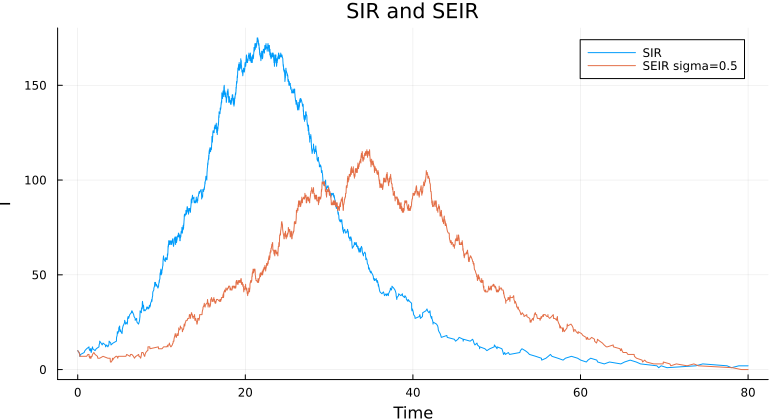

In [1]:
using DrWatson
@quickactivate "ContactEpidemics"
using ContactEpidemics.ContactProcesses
using ContactEpidemics.StudyTools
using DataFrames, CSV, Plots, Statistics


rows = NamedTuple[]
figure = plot(xlabel="Time",ylabel="I",title="SIR and SEIR")
for sigma in [Inf,0.5]
    m = simulate(config=Settings(latent=sigma),T=80.0)
    @assert check_balance(m)
    save_run(m;label="latent_$(sigma)",T=80.0)
    d = table(m)
    plot!(figure,d.t,d.I,label=isfinite(sigma) ? "SEIR sigma=0.5" : "SIR")
    push!(rows,(;sigma,run_metrics(m)...,peak_E=maximum(d.E)))
    isfinite(sigma) && draw_states(m,"seir-states";title="SEIR compartments")
end
summary = DataFrame(rows)
save_table("seir",summary)
display(summary)
savefig(figure,imagefile("seir"))
display(plot(figure; size=(780,420)))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*